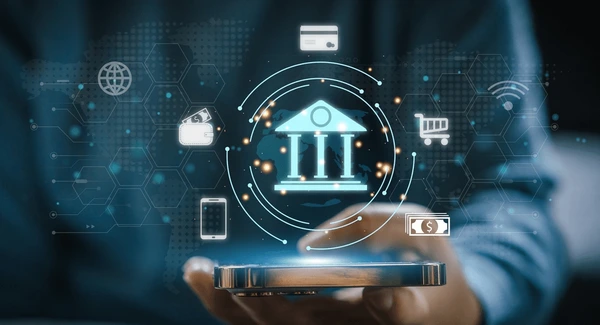

# **AllLife Bank**

## **Problem Statement**

### **Content**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help

### **Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

### **Data Description**


The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

Data Dictionary

Sl_No: Primary key of the records

Customer Key: Customer identification number

Average Credit Limit: Average credit limit of each customer for all credit cards

Total credit cards: Total number of credit cards possessed by the customer

Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

Total visits online: Total number of visits or online logins made by the customer (yearly)

Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)


## **Importing necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the dataset**

In [2]:
## loading the dataset
data = pd.read_excel('/content/sample_data/Credit Card Customer Data.xlsx')

## **Overview of the Dataset**

### **Displaying first 5 and last 5 rows of the dataset**

In [3]:
# viewing the first 5 rows of the data
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [4]:
# viewing the last 5 rows of the data
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


### **Checking the shape of the dataset**

In [5]:
data.shape

(660, 7)

**Observations:**

* The dataset has 660 rows and 7 columns

### **Creating a copy of original data**

In [6]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

### **Checking the data types of the columns for the dataset**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


**Observations:**

* There are Seven columns and all the columns belongs to integer type.
* There are no missing values.

### **Checking for duplicates values**

In [8]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

**Observations:**

* There are no duplicate rows present in the dataset.

### **Checking the missing values**

In [9]:
# checking for missing values
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


**Observations:**

* There are no missing values in the dataset.

### **Removing Unwanted Column from the dataset**

In [10]:
# we will drop the Sl_No and Customer Key column since it adds no value to the analysis
df.drop(["Sl_No", 'Customer Key'], axis=1, inplace=True)

In [11]:
df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3
...,...,...,...,...,...
655,99000,10,1,10,0
656,84000,10,1,13,2
657,145000,8,1,9,1
658,172000,10,1,15,0


### **Getting the statistical summary for the dataset**

In [12]:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


**Observations:**

* Most people have a credit limit around ₹18,000, but a few have very high limits up to ₹2,00,000.

* Usually, customers keep 3 to 6 credit cards.

* Bank visits are low mostly between 1 to 4 times,  some people use it up to 5 times.

* Online visits mostly between 1 to 4 times, some people use it up to 15 times.

* Calls to the bank are mostly 1 to 5, but some make up to 10 calls.


### **Viewing the unique values in each columns**

In [13]:
# view what are the values in object data types
cat_columns = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
for i in cat_columns:
    print(df[i].value_counts())
    print("*" * 50)

Avg_Credit_Limit
8000      35
6000      31
9000      28
13000     28
19000     26
10000     26
11000     24
7000      24
18000     23
14000     23
17000     23
16000     22
5000      21
20000     20
12000     18
15000     17
36000     11
70000     10
38000      8
50000      8
39000      7
56000      7
68000      7
37000      6
41000      6
52000      6
74000      6
47000      6
30000      6
48000      6
34000      6
60000      5
29000      5
26000      5
65000      5
31000      5
51000      4
66000      4
64000      4
49000      4
59000      4
33000      4
73000      4
69000      4
54000      4
71000      4
100000     3
46000      3
44000      3
58000      3
67000      3
61000      3
72000      3
40000      3
45000      3
62000      3
28000      3
57000      3
32000      2
75000      2
35000      2
27000      2
172000     2
163000     2
63000      2
42000      2
166000     2
195000     2
84000      2
156000     2
3000       1
157000     1
96000      1
131000     1
94000      1
25000   

In [14]:
# Printing unique values
for i in df.columns:
  print(f'{i}: {df[i].nunique()}')

Avg_Credit_Limit: 110
Total_Credit_Cards: 10
Total_visits_bank: 6
Total_visits_online: 16
Total_calls_made: 11


**Observations:**

* In Avg_Credit_Limit column there are 110 unique values.

* In Total_Credit_Cards column there are 10 unique values.

* In Total_Visits_bank column there are 6 unique values.

* In Total_Visits_online column there are 16 unique values.

* In Total_calls_made column there are 11 unique values.


## **Exploratory Data Analysis**

### **Functions for EDA**

In [15]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Univariate Analysis**

#### **Observations on Avg_Credit_Limit**

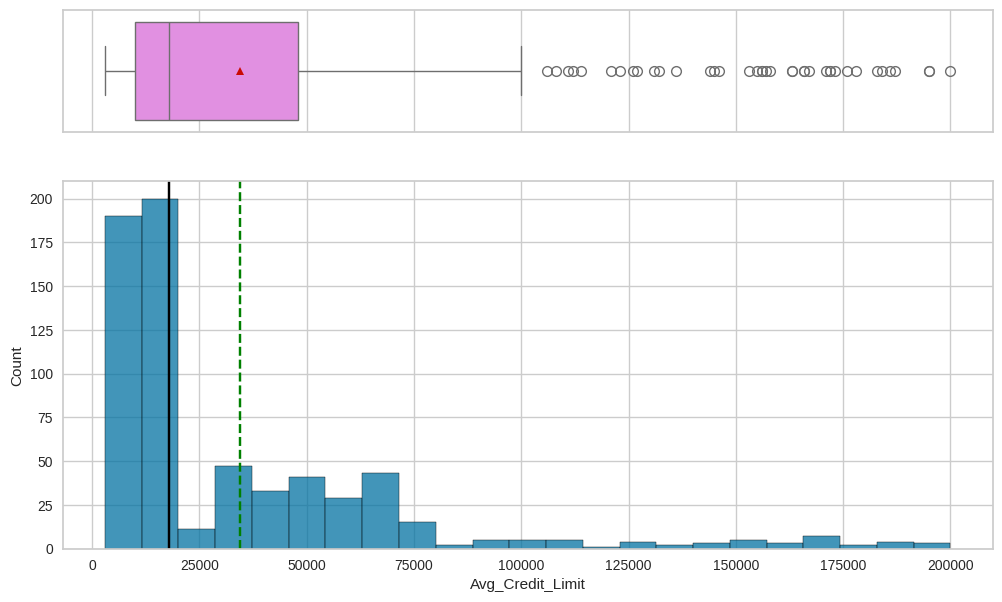

In [17]:
histogram_boxplot(df, 'Avg_Credit_Limit')

**Observations:**

* Most people have a credit limit below ₹50,000.

* A few customers have very high limits up to ₹2,00,000.

* The chart is pulled to the right, showing higher values for some people.

* There are many outliers with very high credit limits.

#### **Observations on Total_Credit_Cards**

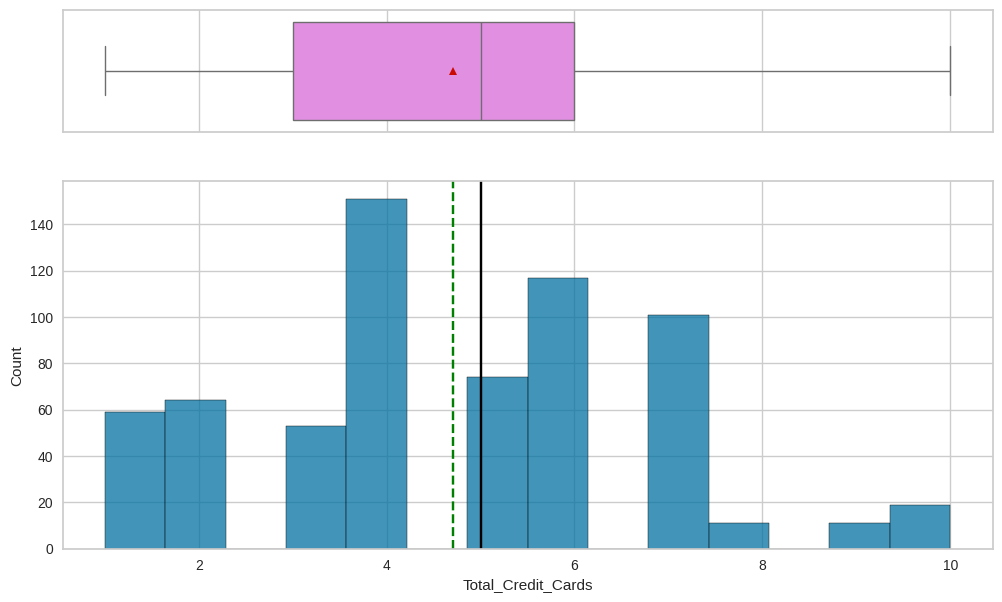

In [18]:
histogram_boxplot(df, 'Total_Credit_Cards')

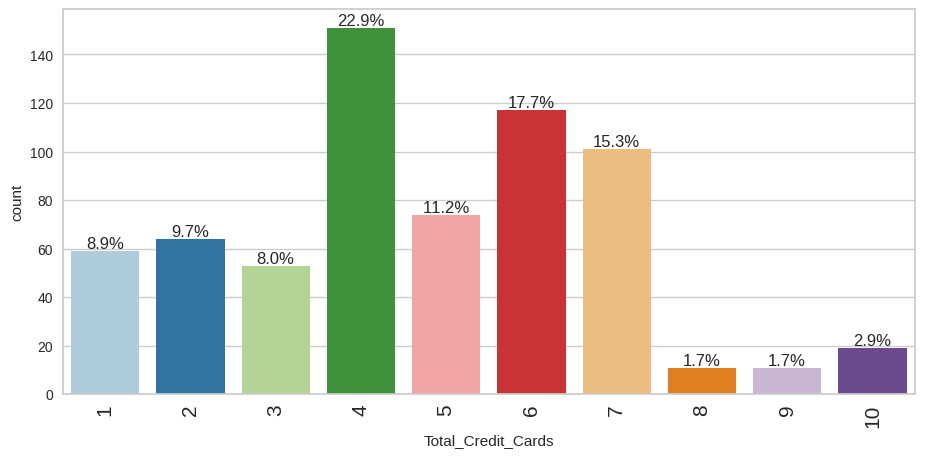

In [19]:
labeled_barplot(df, 'Total_Credit_Cards', perc=True)

**Observations:**

* Most people have 4 credit cards (about 23%).

* Many also have 6 (18%) or 7 (15%) cards.

* Fewer people have 1–3 cards.

* Very few have 8, 9, or 10 cards.

* Having 4–7 credit cards is most common, while very high or very low card counts are rare.

* The data is fairly balanced, with no extreme outliers.

#### **Observations on Total_visits_bank**

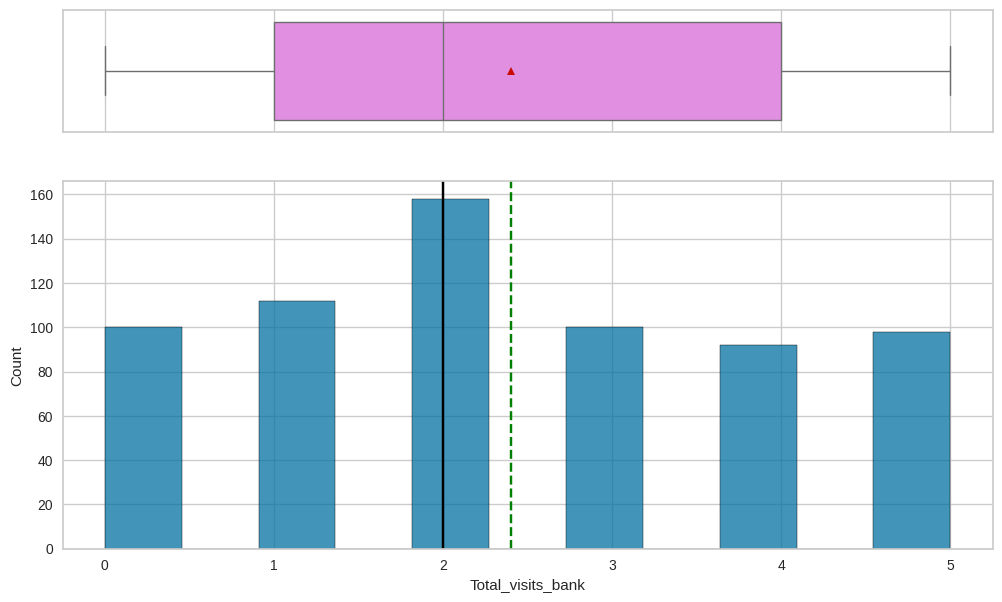

In [20]:
histogram_boxplot(df, 'Total_visits_bank')

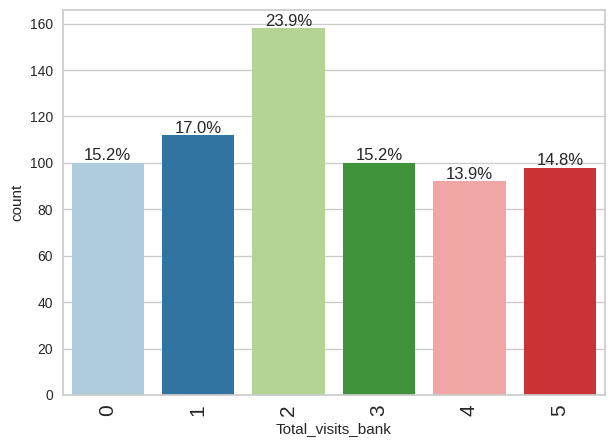

In [21]:
labeled_barplot(df, 'Total_visits_bank', perc=True)

**Observations:**

* Most customers visit the bank about 2 times(about 24%).

* Visits of 1, 3, 4, and 5 times are also common (around 14–17% each).

* Visits range from 0 to 5, so no extreme outliers.

* The distribution looks fairly spread out, with customers visiting at different levels.

* Both the mean and median are around 2 visits, showing balance.

#### **Observations on Total_visits_online**

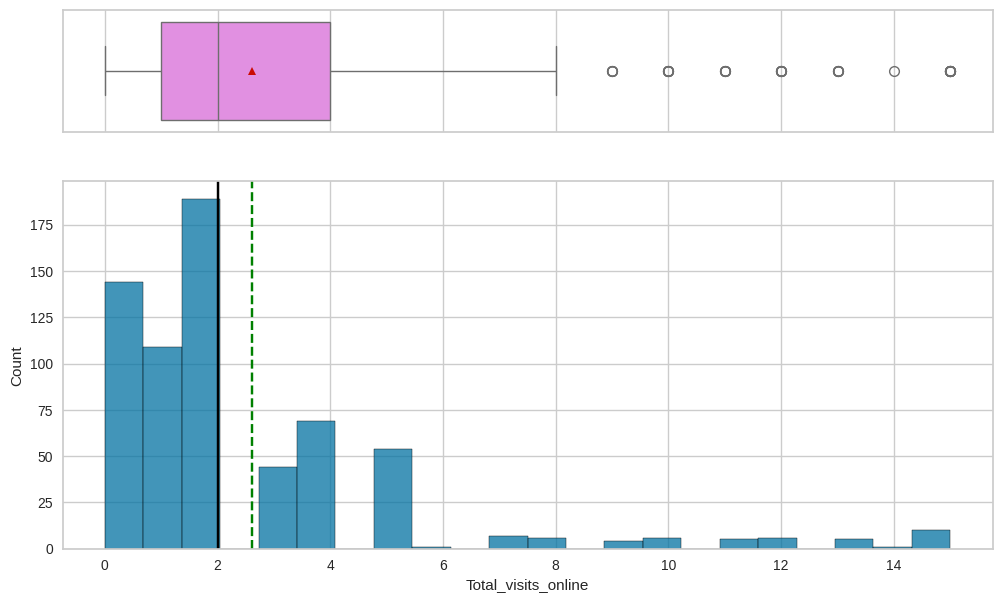

In [22]:
histogram_boxplot(df, 'Total_visits_online')

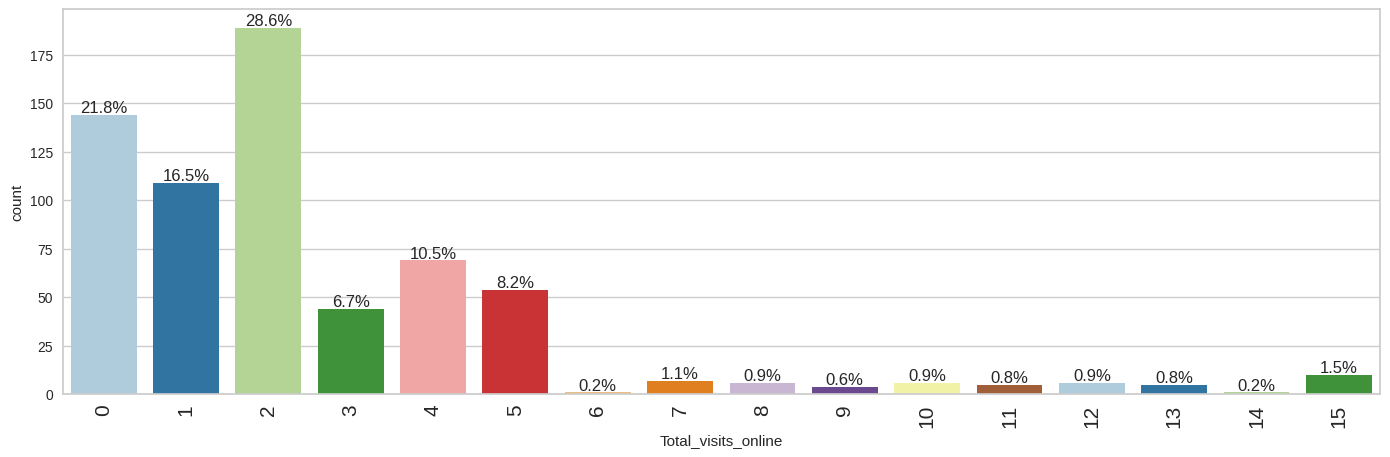

In [23]:
labeled_barplot(df, 'Total_visits_online', perc=True)

**Observations:**

* Most customers visit online 1 to 2 times(about 22% to 29%).

* Smaller groups visit 3–5 times (7–11%).

* Very few people use online services more than 6 times (less than 2% each).

* A few customers visit much more (up to 15 times), which appear as outliers.

* The data is right-skewed, meaning many low values and few very high ones.

* The majority of customers make low to moderate online visits.

#### **Observations on Total_calls_made**

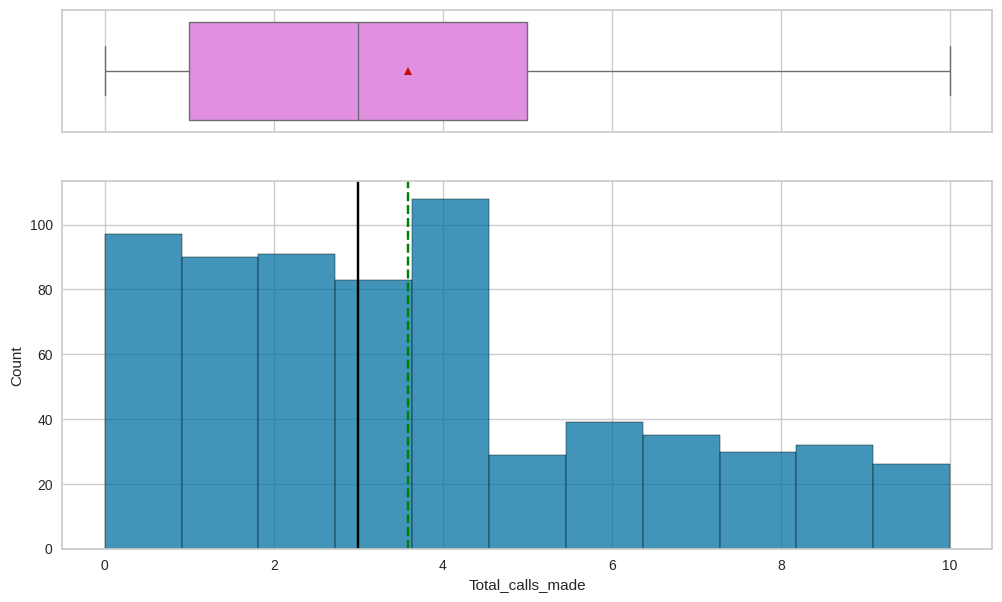

In [24]:
histogram_boxplot(df, 'Total_calls_made')

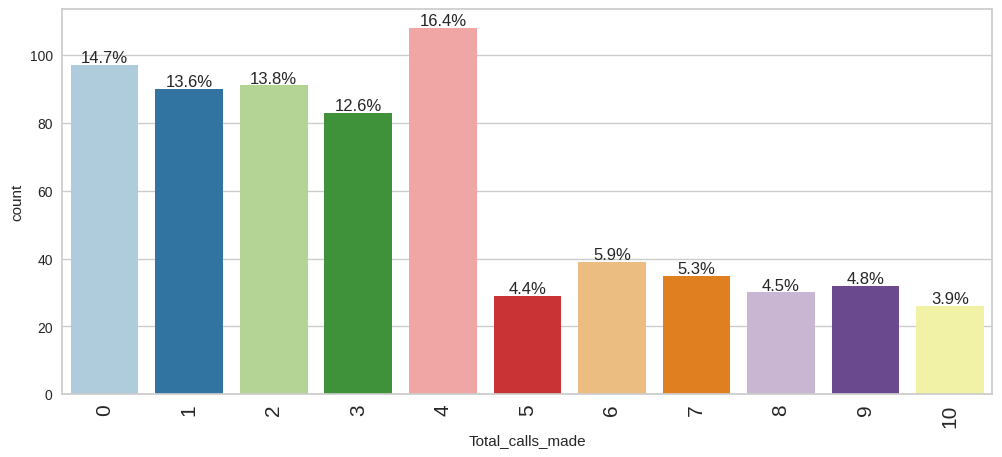

In [25]:
labeled_barplot(df, 'Total_calls_made', perc=True)

**Observations:**

* Most customers make about 4 calls (about 16%).

* Some customers make very few calls 0–3 calls (each around 13–15%).

* Fewer customers make 5 or more calls (each below 6%).

* The data is fairly spread out across the range.

* There are no extreme outliers, and calls are distributed more evenly than visits.

####**Plot of Numerical Variables**

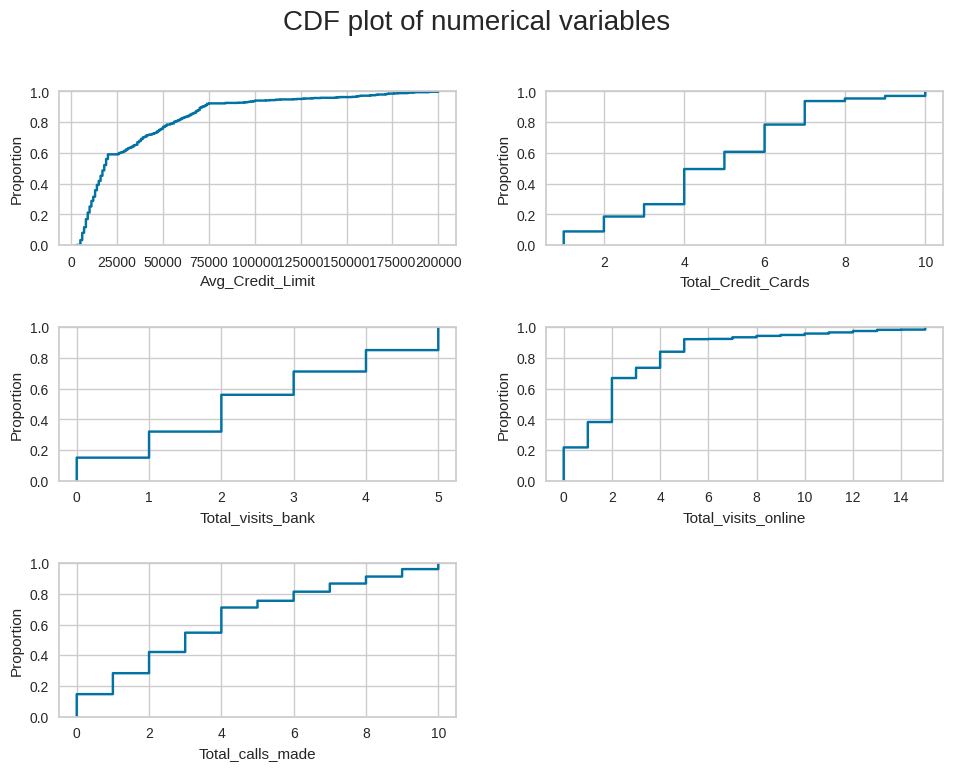

In [26]:
# select numerical columns
all_col = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 2,  figsize=(10, 8))
fig.suptitle('CDF plot of numerical variables', fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0],x=df[all_col[counter]])
    counter = counter+1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1],x=df[all_col[counter]])
        counter = counter+1
    else:
        pass
axes[2,1].set_axis_off();


fig.tight_layout(pad=2.0)

### **Bivarient Analysis**

#### **Observation on Correlation Matrix on Numerical Variables**

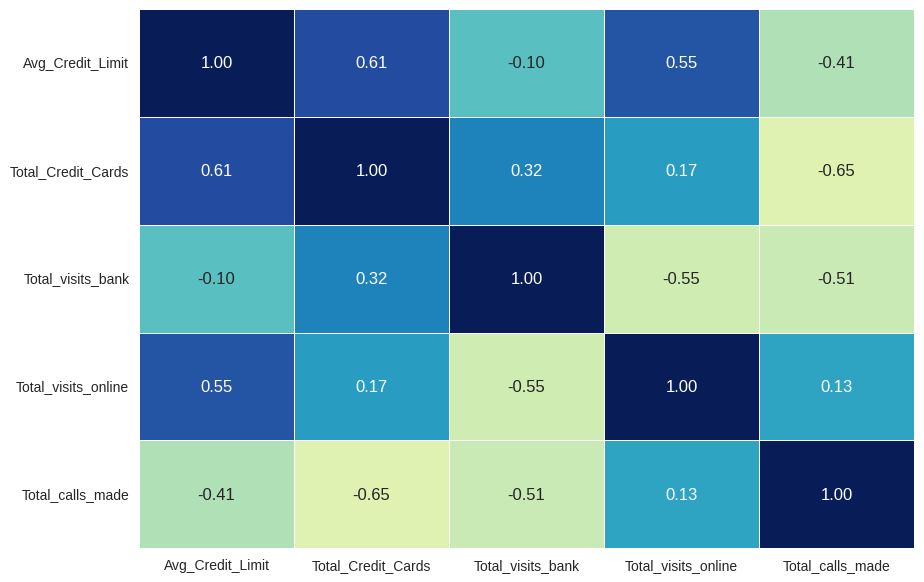

In [27]:
plt.figure(figsize=(10,7))

sns.heatmap(df[all_col].corr(),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="YlGnBu",
            fmt='0.2f')

plt.show()

**Observations:**

* Avg_Credit_Limit has:

    * Strong positive correlation with Total_Credit_Cards (0.61).

    * Positive correlation with Total_visits_online (0.55).

    * Negative correlation with Total_calls_made (-0.41).

* Total_Credit_Cards has:

    * Moderate positive correlation with Total_visits_bank (0.32).

    * Strong negative correlation with Total_calls_made (-0.65).

* Total_visits_bank has:

    * Strong negative correlation with Total_visits_online (-0.55).

    * Moderate negative correlation with Total_calls_made (-0.51).

* Total_visits_online has:

    * Slight positive correlation with Total_calls_made (0.13).

* Total_calls_made generally shows negative correlations with most variables (except a weak positive with online visits).

#### **Observation on all the column using pairplot**

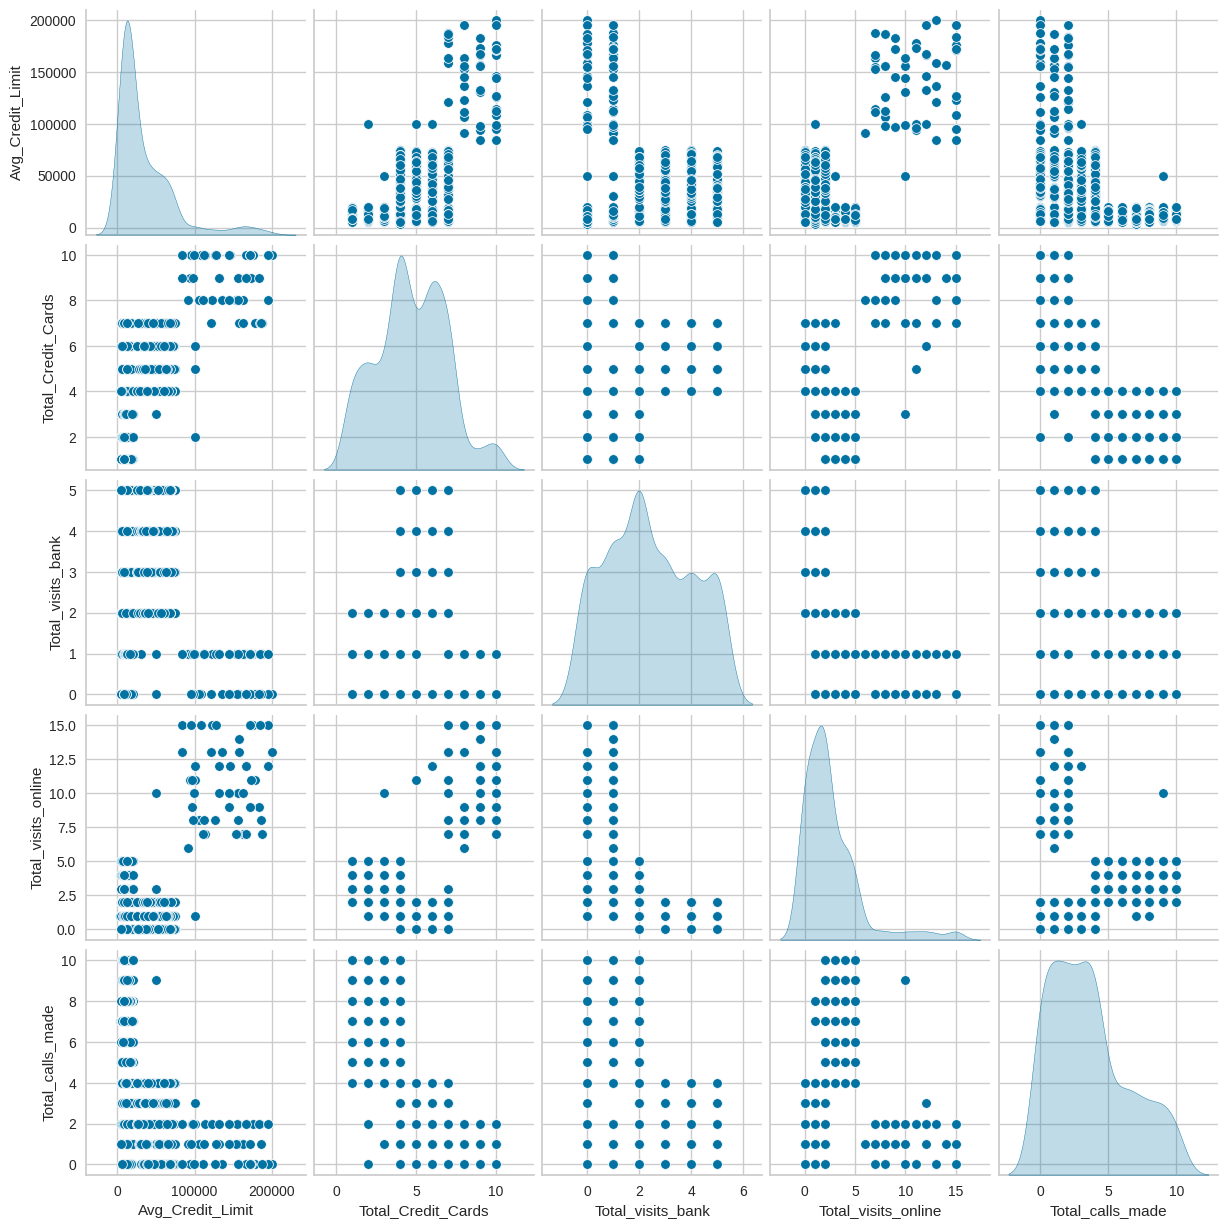

In [28]:
sns.pairplot(data=df[all_col], diag_kind="kde")
plt.show()

**Observations:**

* Most customers are low usage – they have low credit limits, few cards, few visits, and few calls.

* Customers with higher credit limits and more cards prefer online banking and make fewer calls.

* Customers who visit the bank more tend to use online less and call more.

* Only a small group of customers stand out with very high credit limits, many cards, or heavy usage.

#### **Observations Between Total_Credit_Cards and Avg_Credit_Limit**

<Axes: xlabel='Total_Credit_Cards', ylabel='Avg_Credit_Limit'>

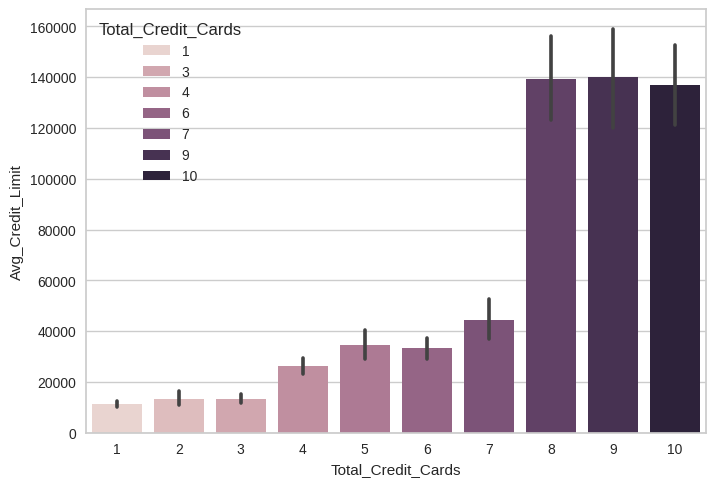

In [29]:
sns.barplot(df, x='Total_Credit_Cards', y='Avg_Credit_Limit', hue='Total_Credit_Cards')

**Observations:**

* Having just one or two cards means a small credit limit.

* The more credit cards a person has, the bigger their total limit gets.

* After about seven cards, the average credit limit jumps up by a lot.

* People with the most cards have the most credit to spend, but the amount can vary a lot between different people.

#### **Observations on Total_Credit_Cards and Total_calls_made**

<Axes: xlabel='Total_Credit_Cards', ylabel='Total_calls_made'>

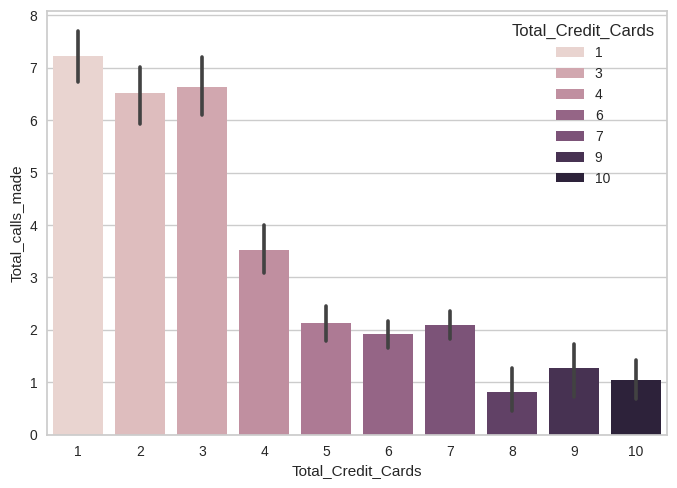

In [30]:
sns.barplot(df, x='Total_Credit_Cards', y='Total_calls_made', hue='Total_Credit_Cards')

**Observations:**

* Most customers made between 0 and 3 calls (majority of the data is concentrated there).


* Very few customers made more than 5 calls.


* The distribution is right-skewed, meaning higher call counts are rare compared to lower ones.



*Overall, the majority of customers contact only a few times, while a small group contacts very frequently.

#### **Observations on Total_Credit_Cards and Total_visits_bank**

<Axes: xlabel='Total_Credit_Cards', ylabel='Total_visits_bank'>

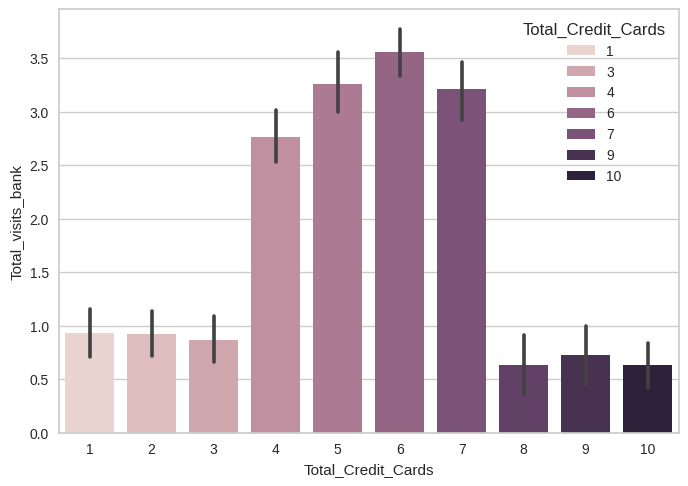

In [31]:
sns.barplot(df, x='Total_Credit_Cards', y='Total_visits_bank', hue='Total_Credit_Cards')

**Observations:**

* Customers with 4–7 credit cards make the highest number of bank visits.


* Customers with very few cards (1–2) or many cards (9–10) visit the bank less often.


* The distribution looks concentrated in the mid-range (4–7 cards), showing that moderate cardholders interact with the bank more frequently.



* Overall, customers with a balanced number of credit cards tend to engage with the bank more than those at the extremes.

#### **Observations on Total_Credit_Cards and Total_visits_online**

<Axes: xlabel='Total_Credit_Cards', ylabel='Total_visits_online'>

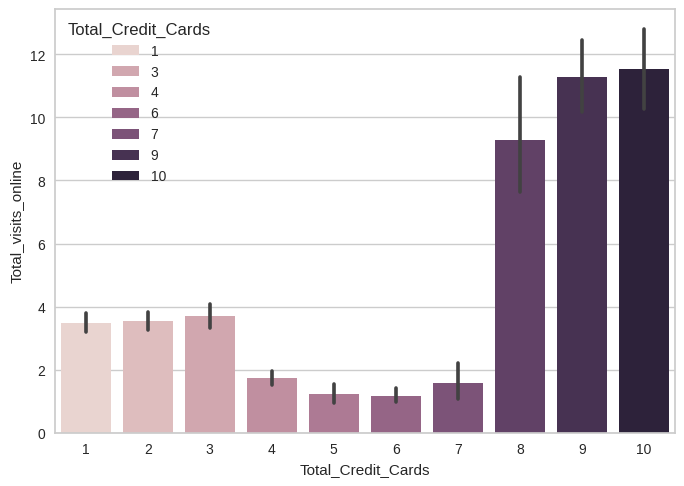

In [32]:
sns.barplot(df, x='Total_Credit_Cards', y='Total_visits_online', hue='Total_Credit_Cards')

**Observations:**

* Customers with higher number of credit cards (8–10) make the most online visits.


* Customers with fewer cards (1–3) rarely use online channels.

* Overall, more credit card users rely more on online platforms compared to customers with fewer cards.

#### **Observations on Total_visits_bank and Total_calls_made**

<Axes: xlabel='Total_visits_bank', ylabel='Total_calls_made'>

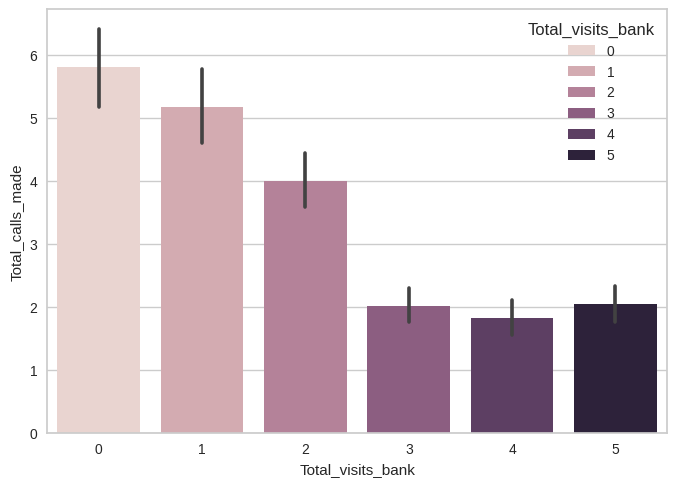

In [33]:
sns.barplot(df, x='Total_visits_bank', y='Total_calls_made', hue = 'Total_visits_bank')

**Observations:**

* Customers with 0–2 bank visits tend to make more calls compared to those with higher visits.


* As bank visits increase (3–5), the number of calls made generally decreases.


* This shows a negative relationship – customers who visit the bank more often usually make fewer calls.


#### **Observations on Total_visits_online and Total_calls_made**


<Axes: xlabel='Total_visits_online', ylabel='Total_calls_made'>

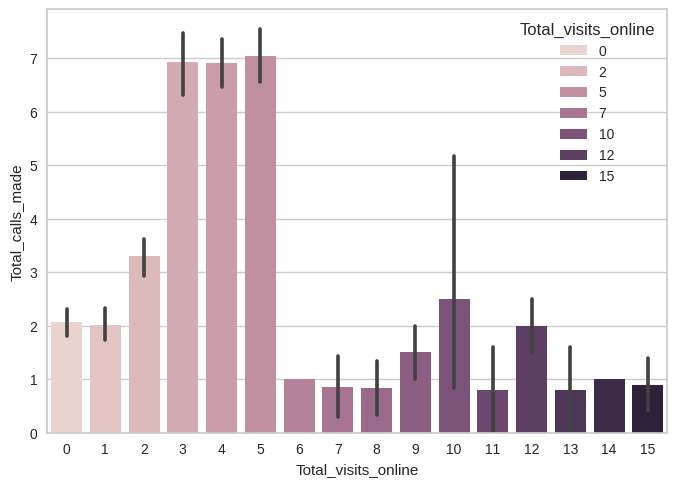

In [34]:
sns.barplot(df, x='Total_visits_online', y='Total_calls_made', hue = 'Total_visits_online')

**Observations:**

* Customers with moderate online visits (3–6 times) tend to make the highest number of calls.


* Customers with very high online visits (10–15 times) make fewer calls, suggesting they rely more on digital channels.


* Customers with low online visits (0–2 times) also keep their calls relatively low.

## **Data Preprocessing**

**Data Preprocessing**

* Missing value treatment (if needed)

* Outlier Detection and Treatment (with rationale if needed)

* Feature Engineering (with rationale if needed)

* Data Scaling (with rationale if needed)


### **Missing value treatment**

In [35]:
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


**Observations:**

* There are no missing value in the given dataset.

### **Outlier detection and treatment**


#### **Detecting Outliers**

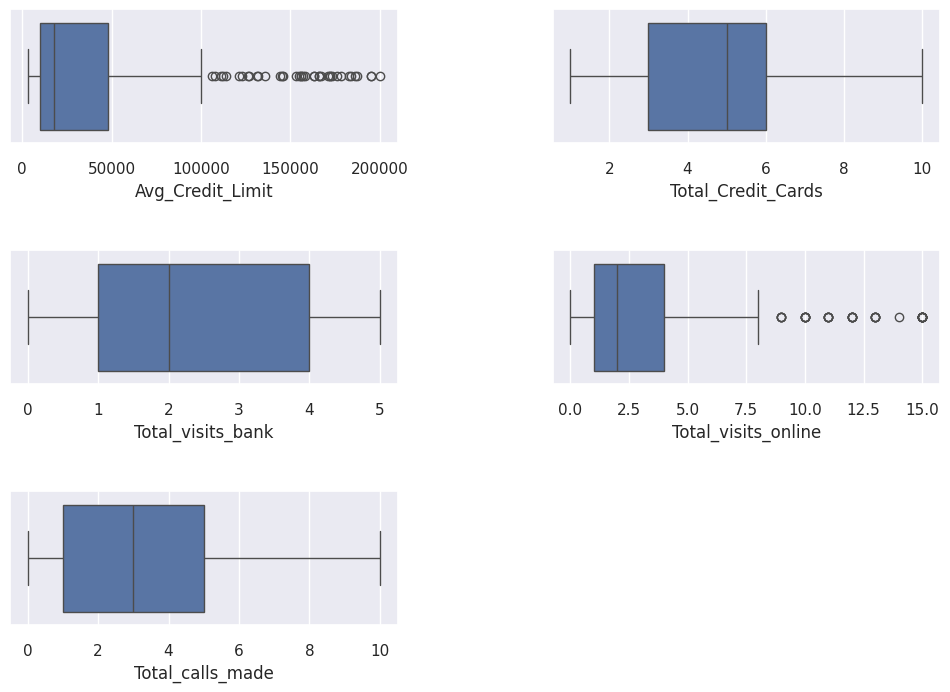

In [36]:
# Visually checking distributions
sns.set(font_scale=1)
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3,2, figsize=(12,8))
fig.subplots_adjust(hspace=0.8, wspace=0.4)
for axis, element in zip(axes.flat, numerical_col):
    sns.boxplot(x=df[element], ax=axis)
axes[2,1].set_axis_off();

**Observations:**

* Total_Credit_Crards, Total_visit_bank and Total_calls_made columns has no outliers.

* Avg_Credit_Limit and Total_visits_online columns has outliers.

* We need to treat these outliers.

#### **Treating Outliers**

In [37]:
# Lets treat outliers by flooring and capping
def treat_outliers(df,col):
    '''
    treats outliers in a variable
    df: data frame
    col: name of the feature
    '''

    # Defining quantiles:
    # 25th quantile
    Q1=df[col].quantile(0.25)

    # 75th quantile
    Q3=df[col].quantile(0.75)

    # Inter quantile Q3 - Q1;
    IQR=Q3-Q1

    # Base quantile less 1.5*IQR
    Lower_Whisker = Q1 - 1.5*IQR
    if Lower_Whisker < 0:
        Lower_Whisker = 0


    # Top quantile plus 1.5*IQR
    Upper_Whisker = Q3 + 1.5*IQR


    # assigning max and min value to the array, meaning that outliers will be subscribed by:
    # min (Lower_Whisker)
    # max (Upper_Whisker)
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    # returning clipped data
    return df

def treat_outliers_all(df, col_list):
    '''
    treat outlier in all numerical variables
    col_list: list of numerical variables
    df: data frame
    '''
    # Looping through the data and applying the function "treat_outliers"
    for c in col_list:
        df = treat_outliers(df,c)

    return df

In [38]:
# Applying the outliers treatment
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
numerical_col

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

In [39]:
# passing the columns and the dataframe in order to remove outliers
df_outliers_treated = treat_outliers_all(df,numerical_col)

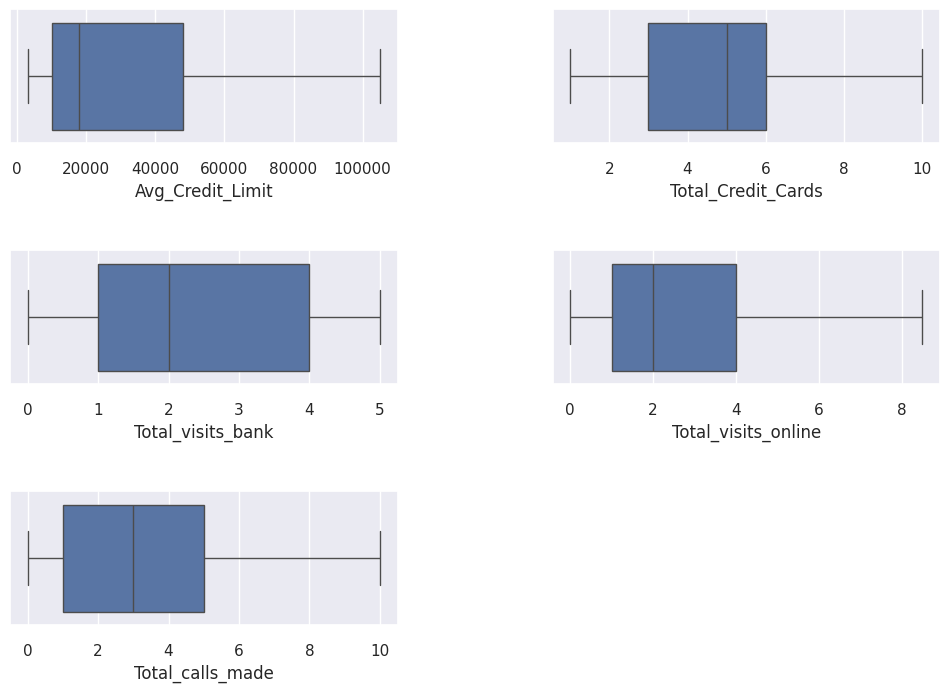

In [40]:
# Visually checking distributions
sns.set(font_scale=1)
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3,2, figsize=(12,8))
fig.subplots_adjust(hspace=0.8, wspace=0.4)
for axis, element in zip(axes.flat, numerical_col):
    sns.boxplot(x=df[element], ax=axis)
axes[2,1].set_axis_off();

In [41]:
# Saving new dataframe
df_outliers = df_outliers_treated.copy()

**Observations:**

* The outliers has been treated completely.

### **Scaling The Data**

In [42]:
# Scaling the dataset before clustering
scaler = StandardScaler()
subset = df_outliers.copy()
subset_scaled = scaler.fit_transform(subset)

In [43]:
# Creating a dataframe of the above results
df_scaled = pd.DataFrame(subset_scaled,columns=subset.columns)

In [44]:
# creating dataframe copies for k-means and hierarchical clustering
km_df = df.copy()
hc_df = df.copy()

## **Model Building**

### **K-means Clustering**

#### **Checking Elbow Plot**

Number of Clusters: 2 	Average Distortion: 1.498614150179638
Number of Clusters: 3 	Average Distortion: 1.4453771012074212
Number of Clusters: 4 	Average Distortion: 1.1283605342109324
Number of Clusters: 5 	Average Distortion: 1.0174604445987463
Number of Clusters: 6 	Average Distortion: 0.9520845194592832
Number of Clusters: 7 	Average Distortion: 0.9148690599262413
Number of Clusters: 8 	Average Distortion: 0.906255138326382
Number of Clusters: 9 	Average Distortion: 0.8828018378682781


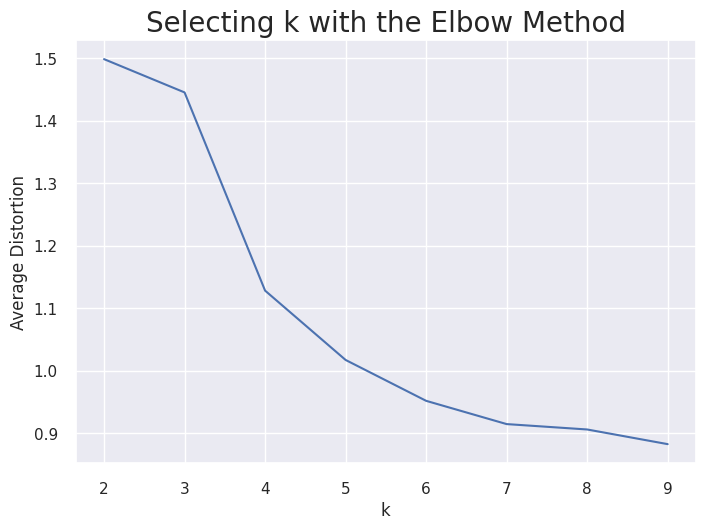

In [45]:
clusters = range(2, 10)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)
    prediction = model.predict(df_scaled)
    distortion = (
        sum(np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1))
        / df_scaled.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

**Let's do further analysis to determine the optimal value of k**

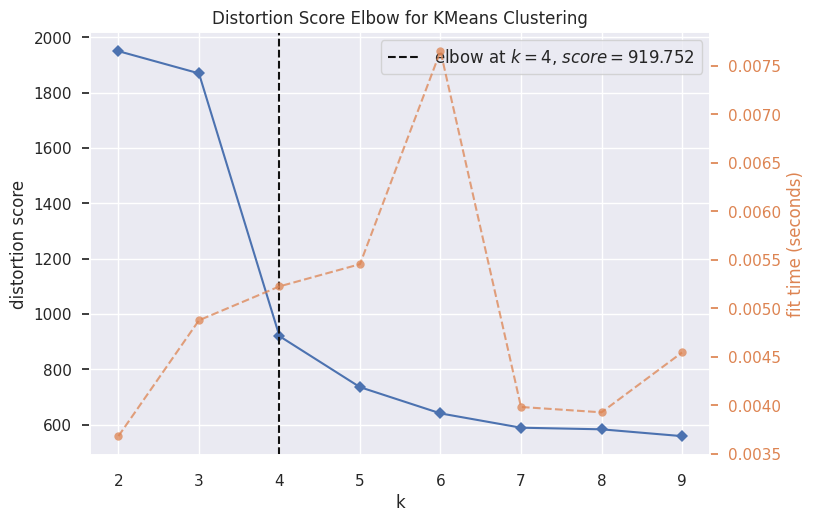

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [46]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 10), timings=True)
visualizer.fit(df_scaled)
visualizer.show()

**The elbow method indicates that the optimal number of clusters for KMeans is
k = 4, as the distortion score begins to level off beyond this point.**


#### **Checking Silhouette Scores**

**Let's check the silhouette scores.**

For n_clusters = 2, the silhouette score is 0.4201583924929177)
For n_clusters = 3, the silhouette score is 0.25291690960327506)
For n_clusters = 4, the silhouette score is 0.3793467288125813)
For n_clusters = 5, the silhouette score is 0.28314046062503906)
For n_clusters = 6, the silhouette score is 0.27151330017797776)
For n_clusters = 7, the silhouette score is 0.26788652745997177)
For n_clusters = 8, the silhouette score is 0.24193441162728857)
For n_clusters = 9, the silhouette score is 0.2410639596707832)


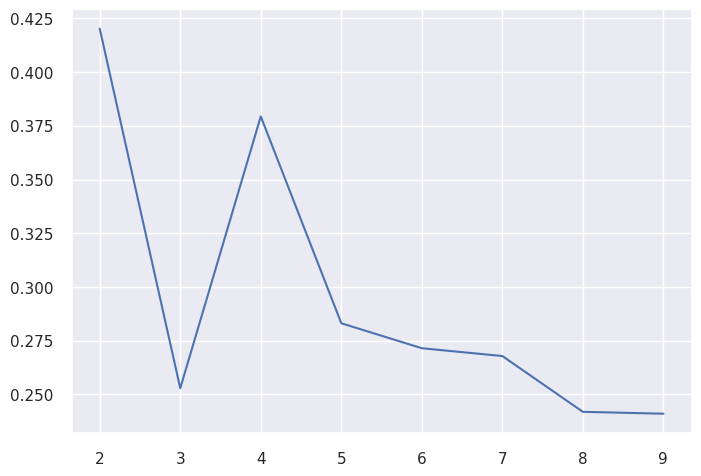

In [47]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((df_scaled))
    score = silhouette_score(df_scaled, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

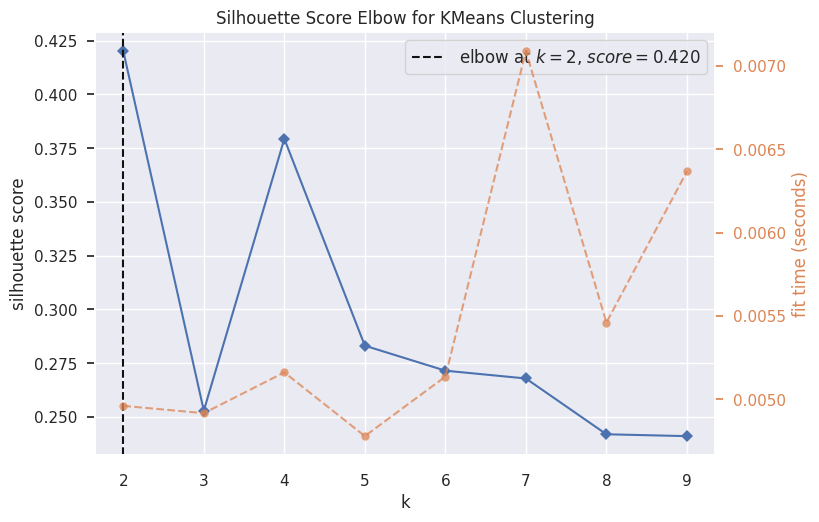

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [48]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 10), metric="silhouette", timings=True)
visualizer.fit(df_scaled)
visualizer.show()

**From the silhouette scores, it seems that 4 is a good value for k.**

**Silhouette Plot**

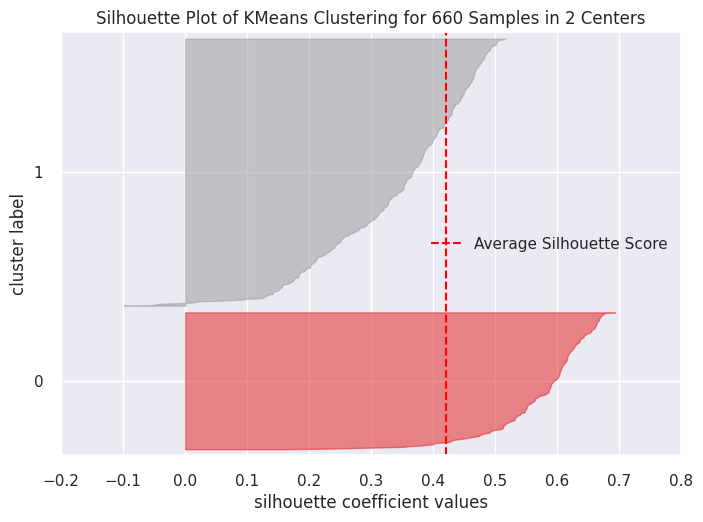

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [49]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

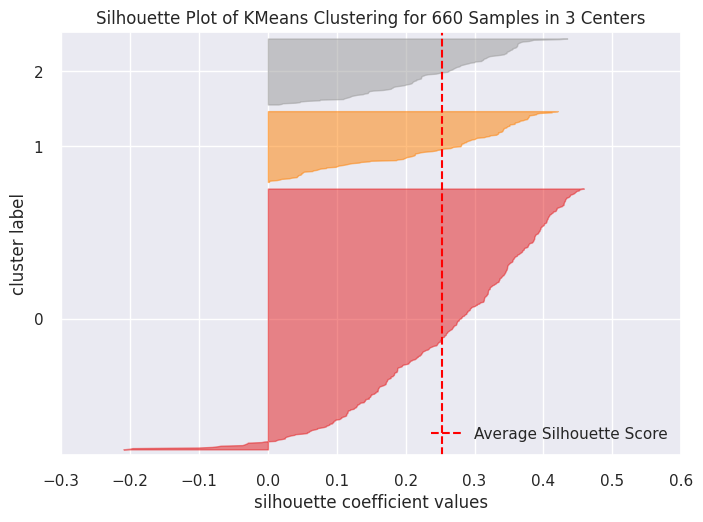

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [50]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

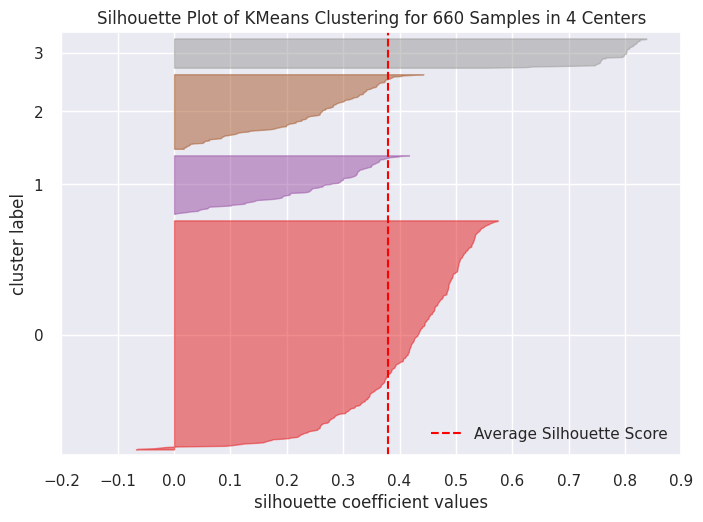

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [51]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

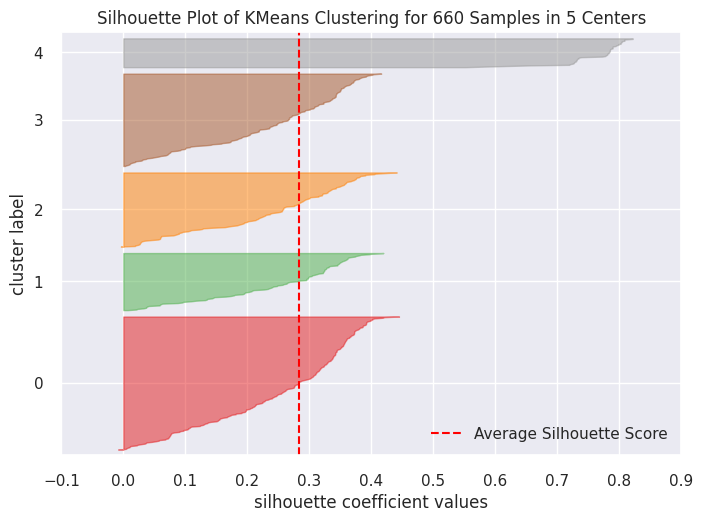

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [52]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

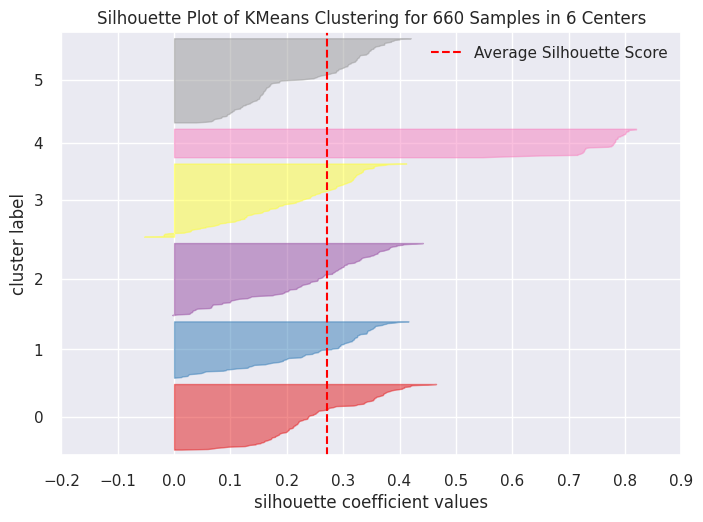

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [53]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

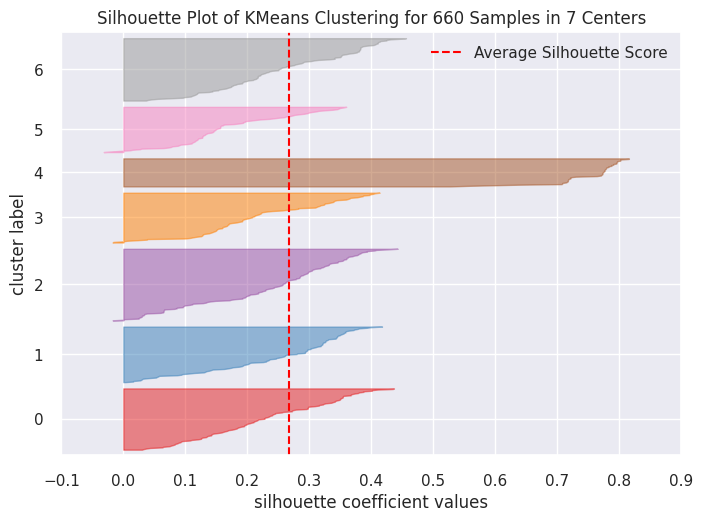

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [54]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

#### **Creating Final Model**

In [55]:
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(df_scaled)

KMeans(n_clusters=4, random_state=1)

In [56]:
# adding kmeans cluster labels to the original dataframe
km_df["KM_segments"] = kmeans.labels_

### **Hierarchical Clustering**

#### **Computing Cophenetic Correlation**

In [57]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(df_scaled, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(df_scaled))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.6666982080229052.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8207884321476555.
Cophenetic correlation for Euclidean distance and average linkage is 0.8926672966587861.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8872365340578665.
Cophenetic correlation for Chebyshev distance and single linkage is 0.6882876568342585.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.7672199195985938.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8907216945489854.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.782728724334691.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.658393428048562.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.388494379210295.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.7998609088477292.
Cophenetic corre

In [58]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8926672966587861, which is obtained with Euclidean distance and average linkage.


#### **Checking Dendrograms**

**We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.**


**Let's view the dendrograms for the different linkage methods.**

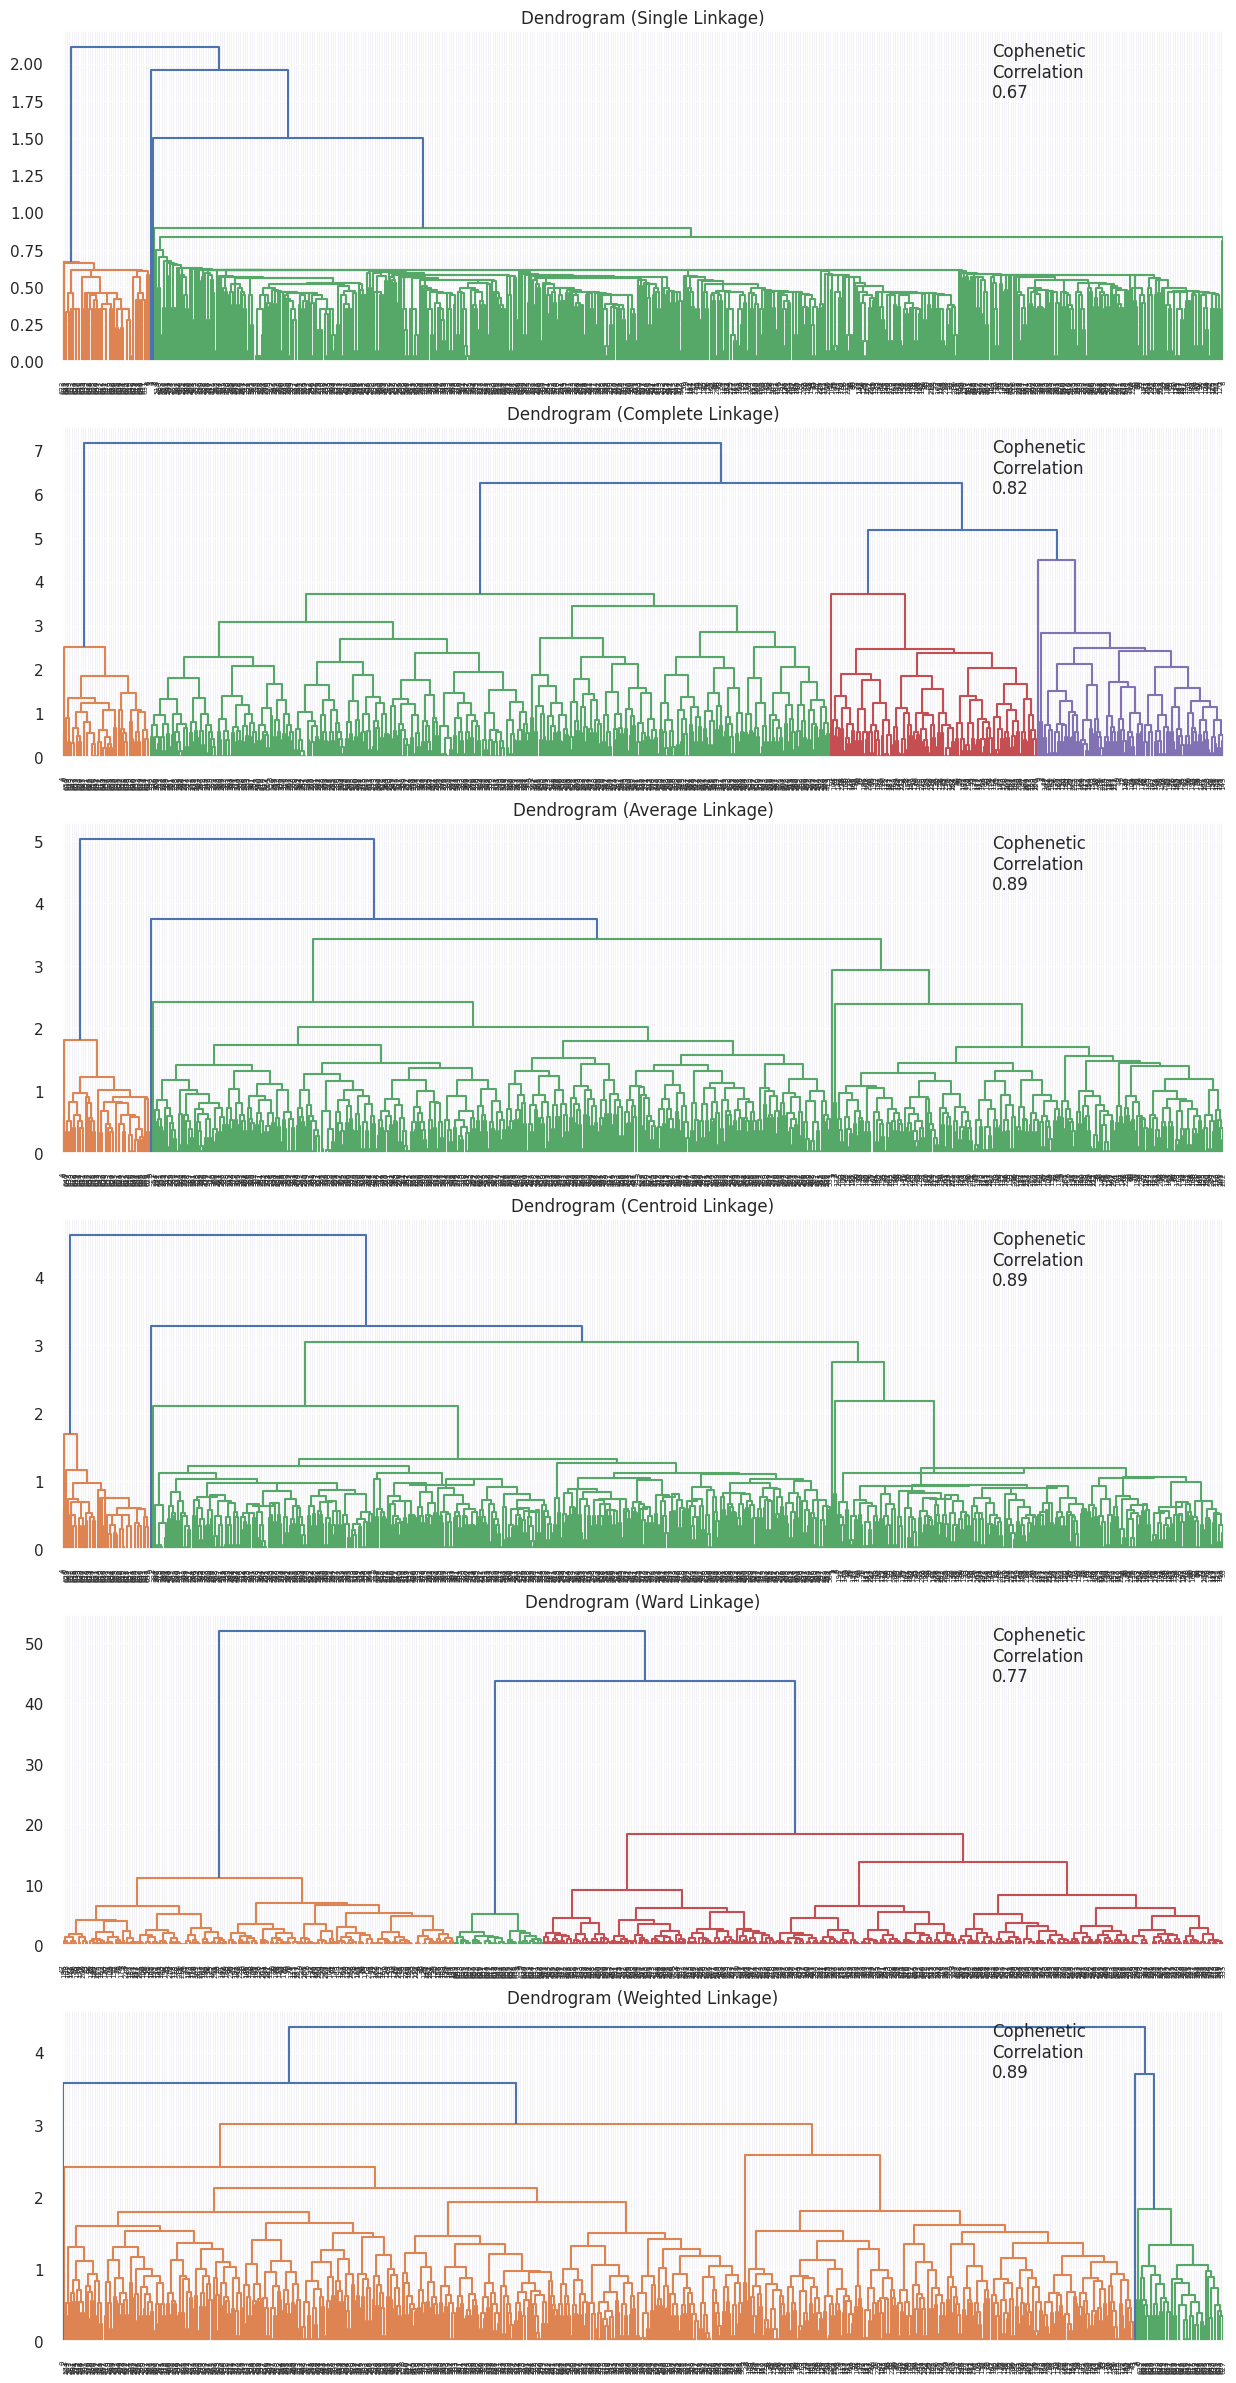

In [59]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(df_scaled, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(df_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

**Observations:**

* Single linkage has the lowest correlation (0.67), so it is not very good.


* Average, Centroid, and Weighted linkage give the highest correlation (0.89).


* Ward linkage has only moderate correlation (0.77) seems to result in the best separation between clusters, even though its cophenetic correlation is lower than the other linkages..


* Complete linkage (0.82) performs better than single but not the best.


* Overall, Average, Centroid, and Weighted are the most reliable choices here.


#### **Creating Final Model**


In [63]:
hc = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="average")
hc_labels = hc.fit_predict(df_scaled)

In [61]:
hc_df["HC_segments"] = hc_labels

## **Cluster Profiling and Comparison**


### **Cluster Profiling: K-means Clustering**

In [ ]:
cluster_profile = km_df.groupby('KM_segments').mean()

In [ ]:
display(cluster_profile)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
KM_segments,,,,,
0,33851.948052,5.516883,3.493506,0.979221,1.994805
1,12464.646465,2.292929,0.888889,3.813131,8.737374
2,11904.761905,2.523810,0.976190,3.325397,5.380952
3,102660.000000,8.740000,0.600000,8.180000,1.080000


In [ ]:
cluster_profile['Freq'] = km_df.groupby('KM_segments')['Avg_Credit_Limit'].count().values

In [ ]:
display(cluster_profile)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Freq
KM_segments,,,,,,
0,33851.948052,5.516883,3.493506,0.979221,1.994805,385
1,12464.646465,2.292929,0.888889,3.813131,8.737374,99
2,11904.761905,2.523810,0.976190,3.325397,5.380952,126
3,102660.000000,8.740000,0.600000,8.180000,1.080000,50


In [ ]:
# lets display cluster profile
cluster_profile.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Freq
KM_segments,,,,,,
0,33851.948052,5.516883,3.493506,0.979221,1.994805,385
1,12464.646465,2.292929,0.888889,3.813131,8.737374,99
2,11904.761905,2.523810,0.976190,3.325397,5.380952,126
3,102660.000000,8.740000,0.600000,8.180000,1.080000,50


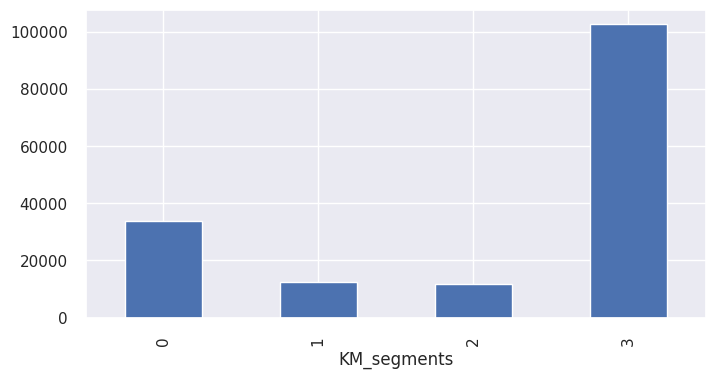

In [ ]:
# Checking the groups for Avg_Credit_Limit
cluster_profile['Avg_Credit_Limit'].plot.bar(figsize=(8,4));

**The bar chart shows that Cluster 3 has the largest number of data points, while Clusters 1 and 2 have the smallest.**

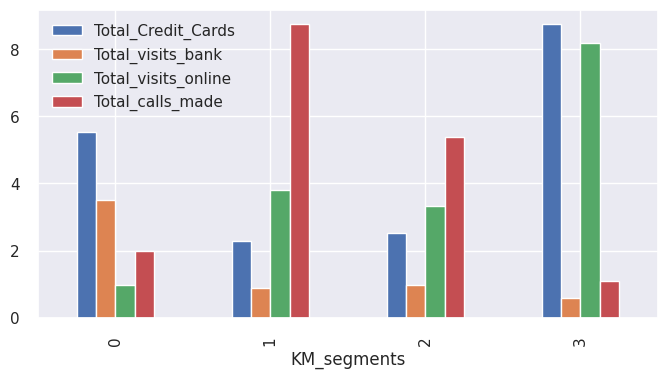

In [ ]:
# Checking the groups for the remainder features
cluster_profile[['Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made']].plot.bar(figsize=(8,4));

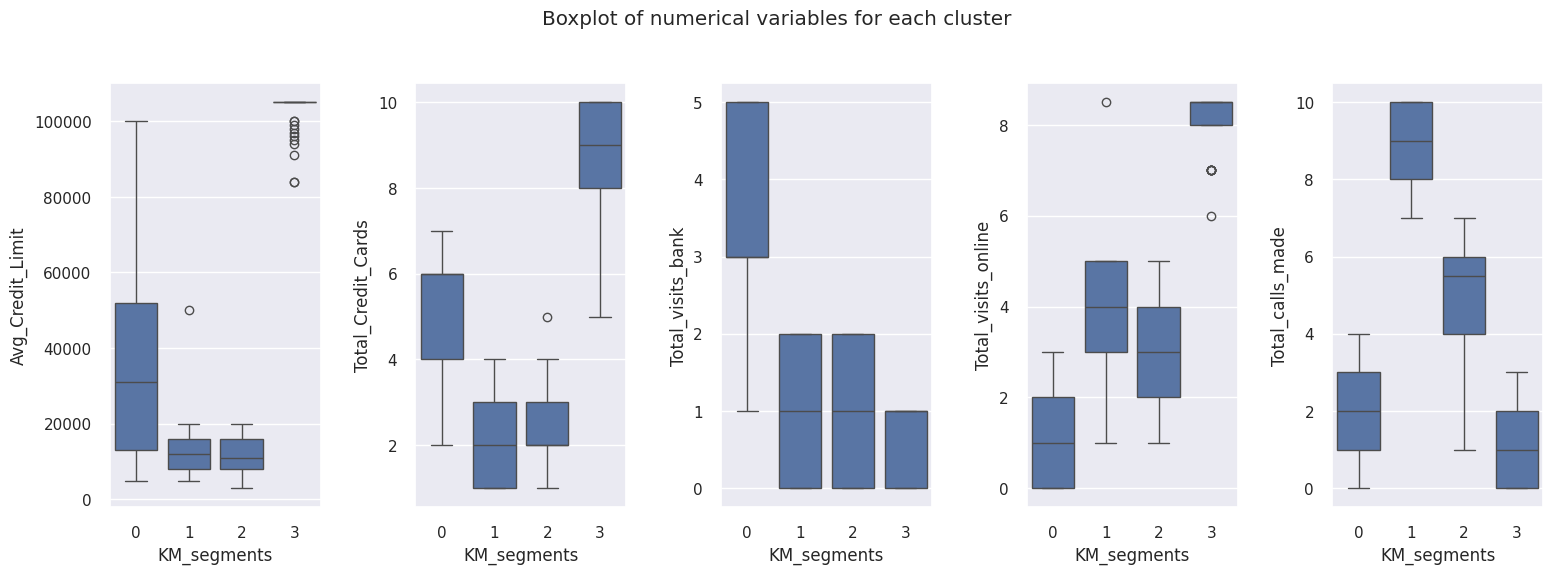

In [ ]:
list_columns =  cluster_profile.columns
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster')
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=km_df[list_columns[counter]],x=km_df['KM_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

#### **Insights**


* Cluster 0 (High Credit & High Engagement)

    * Customers in this group have higher credit limits, multiple credit cards, and frequent visits to both the bank and online channels.

    * They represent the most valuable customer segment, highly engaged with multiple touchpoints.

* Cluster 1 (Low Visits, Limited Usage)

    * Customers here hold fewer credit cards and make very few bank or online visits.

    * Engagement is minimal, suggesting low product usage and limited profitability.

* Cluster 2 (Moderate Users)

    * This group has average credit limits and card usage.

    * They show some engagement across online and offline channels but not at the level of Cluster 0.

    * They represent a growth potential segment if nurtured properly.

* Cluster 3 (Very Low Engagement / At-Risk)

    * Customers in this cluster show nearly no bank or online visits and minimal card activity.

    * They are likely inactive or at risk of churn.

### **Cluster Profiling: Hierarchical Clustering**

In [ ]:
cluster_profile_HC = hc_df.groupby('HC_segments').mean()

In [ ]:
display(cluster_profile_HC)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_segments,,,,,
0,20666.666667,5.474510,3.678431,1.054902,2.054902
1,12197.309417,2.403587,0.928251,3.553812,6.883408
2,102660.000000,8.740000,0.600000,8.180000,1.080000
3,58916.666667,5.583333,3.113636,0.848485,1.909091


In [ ]:
cluster_profile_HC['Freq'] = hc_df.groupby('HC_segments')['Avg_Credit_Limit'].count().values

In [ ]:
display(cluster_profile_HC)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Freq
HC_segments,,,,,,
0,20666.666667,5.474510,3.678431,1.054902,2.054902,255
1,12197.309417,2.403587,0.928251,3.553812,6.883408,223
2,102660.000000,8.740000,0.600000,8.180000,1.080000,50
3,58916.666667,5.583333,3.113636,0.848485,1.909091,132


In [ ]:
# lets display cluster profile
cluster_profile_HC.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Freq
HC_segments,,,,,,
0,20666.666667,5.474510,3.678431,1.054902,2.054902,255
1,12197.309417,2.403587,0.928251,3.553812,6.883408,223
2,102660.000000,8.740000,0.600000,8.180000,1.080000,50
3,58916.666667,5.583333,3.113636,0.848485,1.909091,132


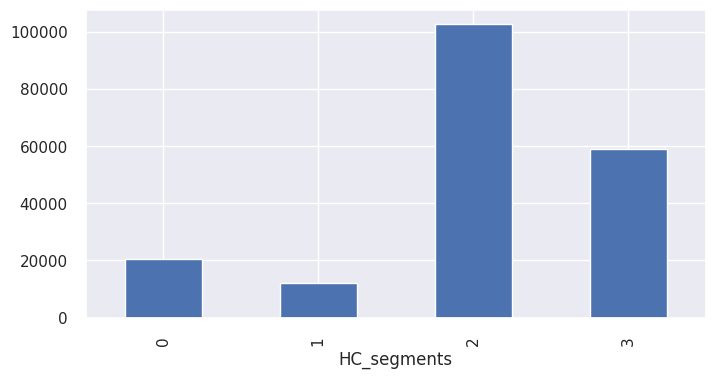

In [ ]:
# Checking the groups for Avg_Credit_Limit
cluster_profile_HC['Avg_Credit_Limit'].plot.bar(figsize=(8,4));

**The bar chart shows that Cluster 2 has the largest number of data points, while Clusters 1 and 3 have the smallest.**

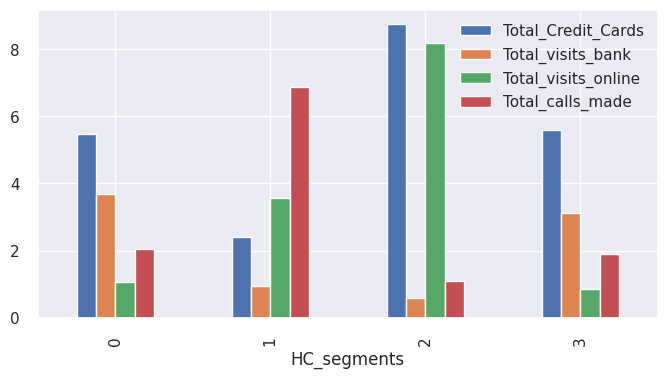

In [ ]:
# Checking the groups for the remainder features
cluster_profile_HC[['Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made']].plot.bar(figsize=(8,4));

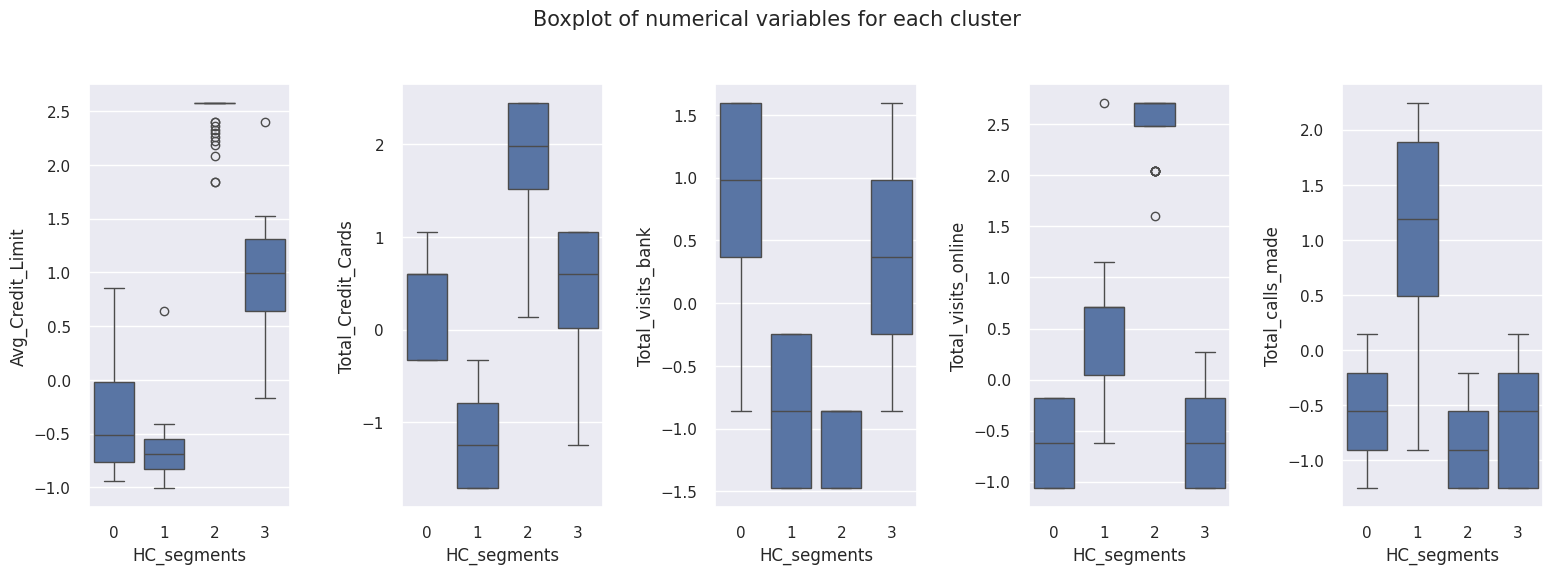

In [ ]:
# Create a DataFrame with scaled data and hierarchical cluster labels
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)
subset_scaled_df['HC_segments'] = hc_df['HC_segments']

fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=15)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=subset_scaled_df[all_col[counter]],x=hc_df['HC_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

#### **Insights:**

* Cluster 0 — Premium & Highly Engaged

    * Customers with high credit limits, multiple credit cards, and frequent bank + online visits.

    * They form the core profitable segment, similar to the K-Means high-value cluster.

* Cluster 1 — Low Usage, Low Engagement

    * Customers with low to moderate credit limits, very few cards, and minimal online/bank interactions.

    * Indicates a group with limited product adoption.

* Cluster 2 — Balanced / Average Users

    * Customers with moderate credit limits and usage patterns.

    * Somewhat engaged, but not as active as Cluster 0.

    * Represents a potential growth segment if provided with incentives.

* Cluster 3 — Inactive / At-Risk Customers

    * Customers with almost no visits to bank or online platforms, very low card activity.

    * Likely inactive or at risk of churn, requiring reactivation strategies.

### **Compare cluster K-means clusters and Hierarchical clusters**

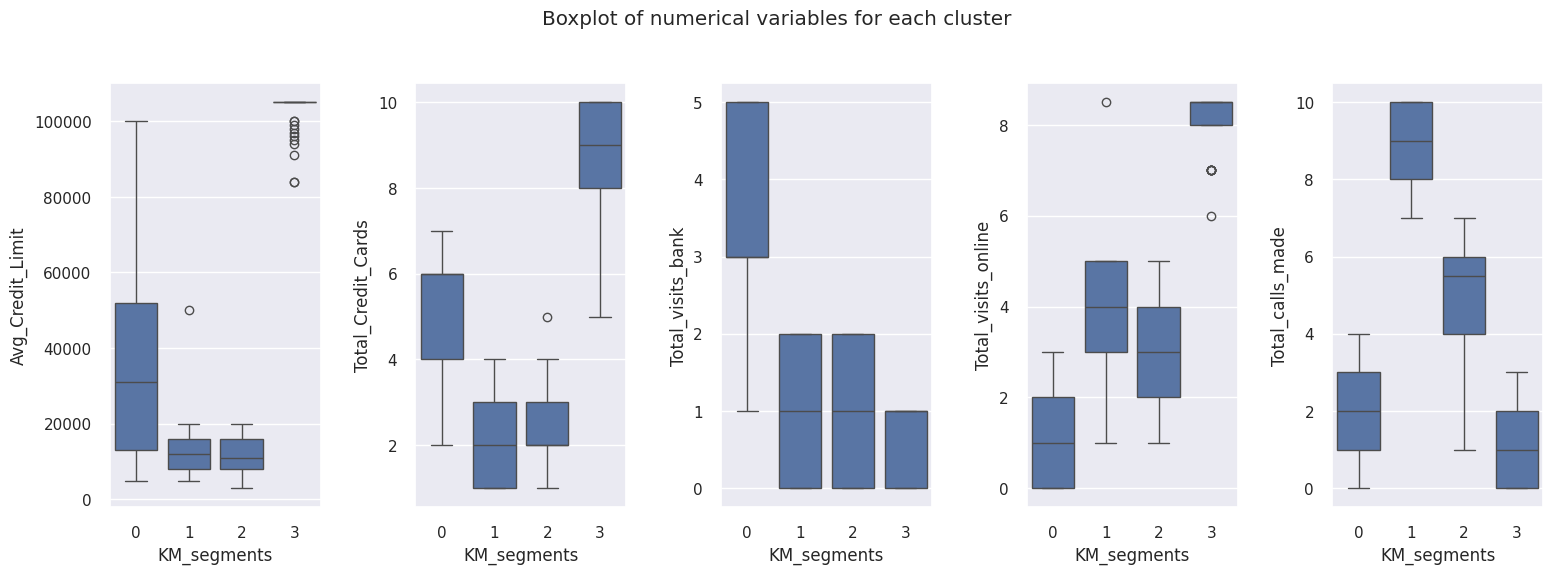

In [ ]:
list_columns =  cluster_profile.columns
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster')
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=df_outliers[list_columns[counter]],x=km_df['KM_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

**Conclusions K-means**

* K-Means produced balanced and compact clusters, with customers grouped mainly by credit limit and engagement level.

* Cluster 0 contained high-value, high-engagement customers (frequent bank/online visits, multiple cards).

* Cluster 1 included low-engagement customers with fewer cards and minimal usage.

* Cluster 2 represented average users with moderate credit limits and moderate engagement.

* Cluster 3 grouped very low-engagement or inactive customers, signaling churn risk.

The silhouette score indicated that K-Means formed well-separated clusters with good cohesion.

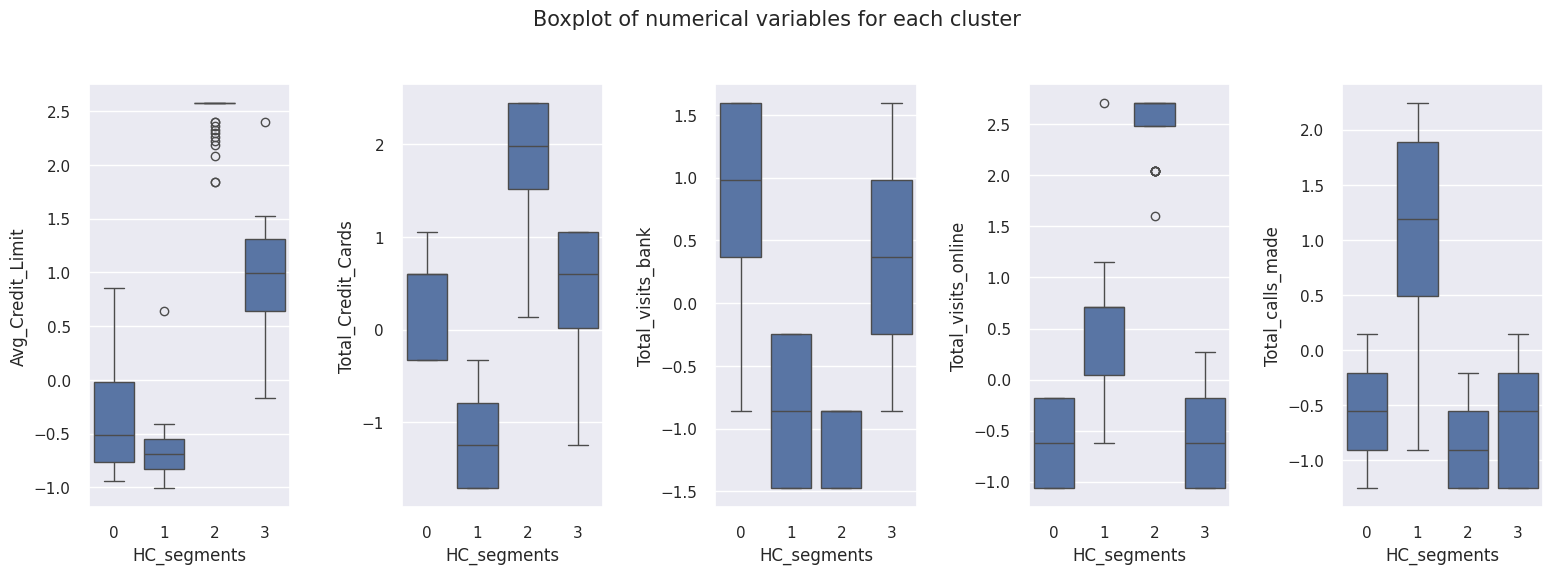

In [ ]:
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=15)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=subset_scaled_df[all_col[counter]],x=hc_df['HC_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

**Conclusions Hierarchical clusters**

* Hierarchical clustering also revealed four distinct customer groups with similar behavioral patterns to K-Means.

* Cluster 0 captured premium customers with higher credit limits and high engagement.

* Cluster 1 grouped low-engagement, low-usage customers.

* Cluster 2 included moderate customers with average engagement and potential to grow.

* Cluster 3 identified customers with extremely low or no activity, likely inactive.

## **Using PCA to reduce the number of variables**

**Let's use PCA to reduce the data to two dimensions and visualize it to see how well-separated the clusters are.**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(df_scaled)

# storing results in a dataframe
reduced_data_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

# checking the amount of variance explained
print(
    f"The first two principal components explain {np.round(100*pca.explained_variance_ratio_.sum(), 2)}% of the variance in the data."
)

The first two principal components explain 81.72% of the variance in the data.


<Axes: xlabel='Component 1', ylabel='Component 2'>

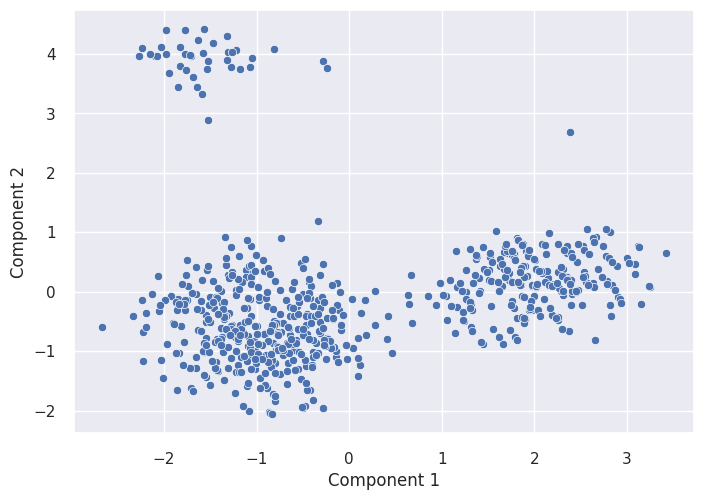

In [ ]:
sns.scatterplot(data=reduced_data_df_pca, x="Component 1", y="Component 2")

<Axes: xlabel='Component 1', ylabel='Component 2'>

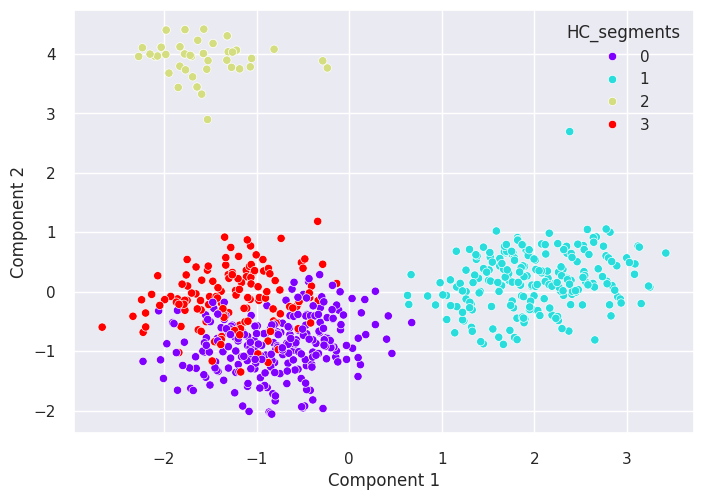

In [ ]:
sns.scatterplot(
    data=reduced_data_df_pca,
    x="Component 1",
    y="Component 2",
    hue=hc_df["HC_segments"],
    palette="rainbow",
)

** The clusters are pretty well separated.**

## **Actional Insights and Recommandations**

### **Actionable Insights**

* Customers are naturally segmented into four behavior groups: premium, moderate, low-usage, and inactive.

* Credit limit and number of cards are the strongest differentiators across clusters.

* Bank and online visit frequency reflects customer engagement and separates active vs. inactive users.

* Cluster 0 (Premium/Engaged) shows the highest profitability potential due to high credit use and engagement.

* Cluster 1 (Low Usage) has very few interactions, suggesting low awareness or limited product fit.

* Cluster 2 (Moderate Users) has mid-level engagement, making them easier to convert to premium users.

* Cluster 3 (Inactive/At-Risk) has almost no activity, signaling potential churn.

* K-Means provides balanced, well-separated clusters, suitable for marketing execution.

* Hierarchical clustering highlights customer relationship patterns, though clusters are less balanced.

* Both methods confirm that engagement level directly correlates with customer profitability.

### **Recommendations**

* Retain Cluster 0 through loyalty programs, exclusive rewards, and priority services.

* Activate Cluster 1 using awareness campaigns, educational content, and simplified onboarding.

* Grow Cluster 2 by offering personalized promotions and cross-selling opportunities.

* Reactivate Cluster 3 with win-back campaigns, fee waivers, and re-engagement offers.

* Launch a tiered customer engagement strategy (Retain → Grow → Activate → Reactivate).

* Invest in digital engagement tools (apps, online services) to improve adoption among low-usage clusters.

* Monitor customer movement between clusters to measure effectiveness of interventions.

* Use K-Means clusters for operational marketing because of their balance and clarity.

* Apply Hierarchical analysis for strategic insights, especially to understand customer relationships.

* Regularly retrain the clustering model with new data to keep segmentation current.